### Dataset Overview
This dataset contains sales data from a sample superstore, including orders, customers, products, and regions. 
It will be used to analyze revenue trends, category performance, and regional contributions.

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df = pd.read_csv("data.csv", encoding='latin1')

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [110]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [111]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
df.drop_duplicates(inplace=True)

In [114]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [115]:
df['Order Date'].dtype

dtype('<M8[us]')

In [116]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [117]:
df.columns = df.columns.str.strip()

In [118]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [119]:
df['Year'] = df['Order Date'].dt.year

In [120]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [121]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month            0
Year             0
dtype: int64

In [122]:
df.duplicated().sum()

np.int64(0)

### Total Revenue
The total revenue across all orders is **$2,297,200.86**, providing a baseline for overall business performance.
This high revenue indicates a sizable and active customer base.

In [123]:
total_sales = df['Sales'].sum()
total_sales

np.float64(2297200.8603)

### Sales by Category
Breaking down sales by category:
- Technology: $836,154.03  
- Furniture: $741,999.80  
- Office Supplies: $719,047.03  

Technology is the top-performing category, suggesting strong demand for tech products. 
Furniture and Office Supplies also contribute significantly, showing balanced revenue streams across categories.

In [124]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

### Top 5 Products
The top 5 revenue-generating products are:

1. Canon imageCLASS 2200 Advanced Copier – $61,599.82  
2. Fellowes PB500 Electric Punch Plastic Comb Binding Machine – $27,453.38  
3. Cisco TelePresence System EX90 Videoconferencing Unit – $22,638.48  
4. HON 5400 Series Task Chairs for Big and Tall – $21,870.58  
5. GBC DocuBind TL300 Electric Binding System – $19,823.48  

These bestsellers account for a substantial portion of total sales and should be prioritized in inventory and marketing strategies.

In [125]:
df.groupby('Product Name')['Sales'] \
  .sum() \
  .sort_values(ascending=False) \
  .head()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

### Sales by Region
Sales breakdown by region:

- West: $725,457.82  
- East: $678,781.24  
- Central: $501,239.89  
- South: $391,721.91  

The West and East regions are the highest revenue-generating areas, suggesting key markets for promotional campaigns and inventory allocation.

In [126]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

### Monthly Sales Trend
Aggregating sales by month shows seasonal patterns and growth trends:

- Q4 (Oct–Dec) consistently has spikes, e.g., Nov 2017 sales reached $118,447.83  
- Lowest months are usually Jan–Feb, e.g., Feb 2015 sales were $11,951.41  

This pattern indicates clear seasonal demand, which can inform inventory planning, marketing strategies, and sales forecasting.

In [127]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

In [128]:
import matplotlib.pyplot as plt

### Monthly Sales Trend
A line chart visualizing sales over time, aggregated by month.
Observing patterns or seasonal spikes (e.g., Q4) can help forecast demand and optimize inventory.

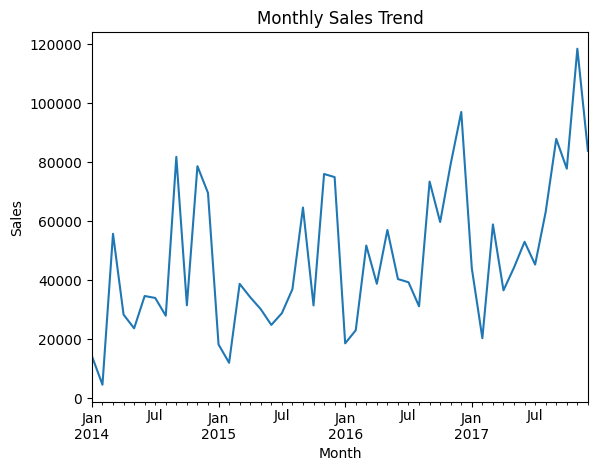

In [129]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Sales by Category
This bar chart shows total sales per product category.
We can identify which categories contribute most to revenue, providing insight into product performance.

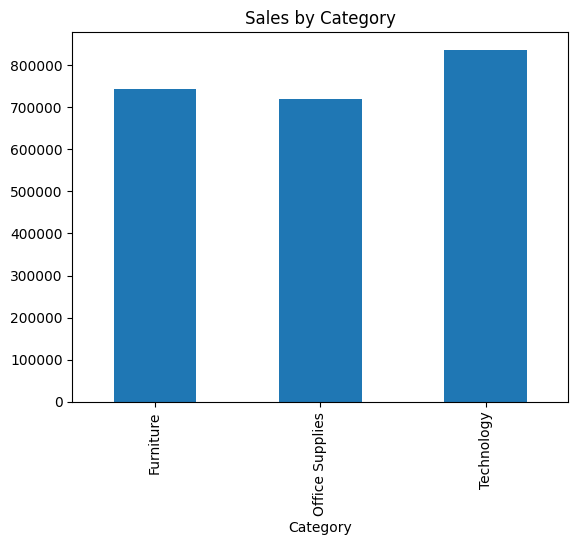

In [130]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

### Top 5 Products
This chart shows the five products generating the highest revenue.
It highlights key bestsellers and helps identify products that may need focused marketing or inventory planning.

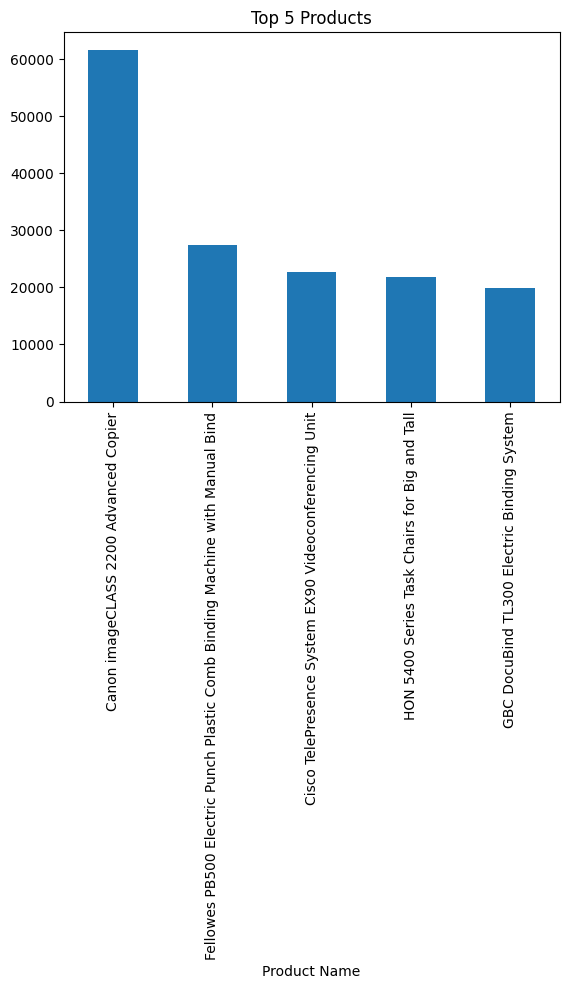

In [131]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(5)

top_products.plot(kind='bar')
plt.title("Top 5 Products")
plt.show()

In [132]:
print("Total Revenue:", df['Sales'].sum())
print("\nSales by Category:\n", df.groupby('Category')['Sales'].sum())
print("\nTop 5 Products:\n", df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head())
print("\nSales by Region:\n", df.groupby('Region')['Sales'].sum())
print("\nMonthly Sales Trend:\n", df.groupby('Month')['Sales'].sum())

Total Revenue: 2297200.8603

Sales by Category:
 Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

Top 5 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Sales by Region:
 Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Monthly Sales Trend:
 Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014